In [2]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 58.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [3]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.1/693.1 kB 27.7 MB/s eta 0:00:00


In [6]:
pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-370qp5ya
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-370qp5ya
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 6a9c8dadac04eb85befc935043e3e2cce914267f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nv

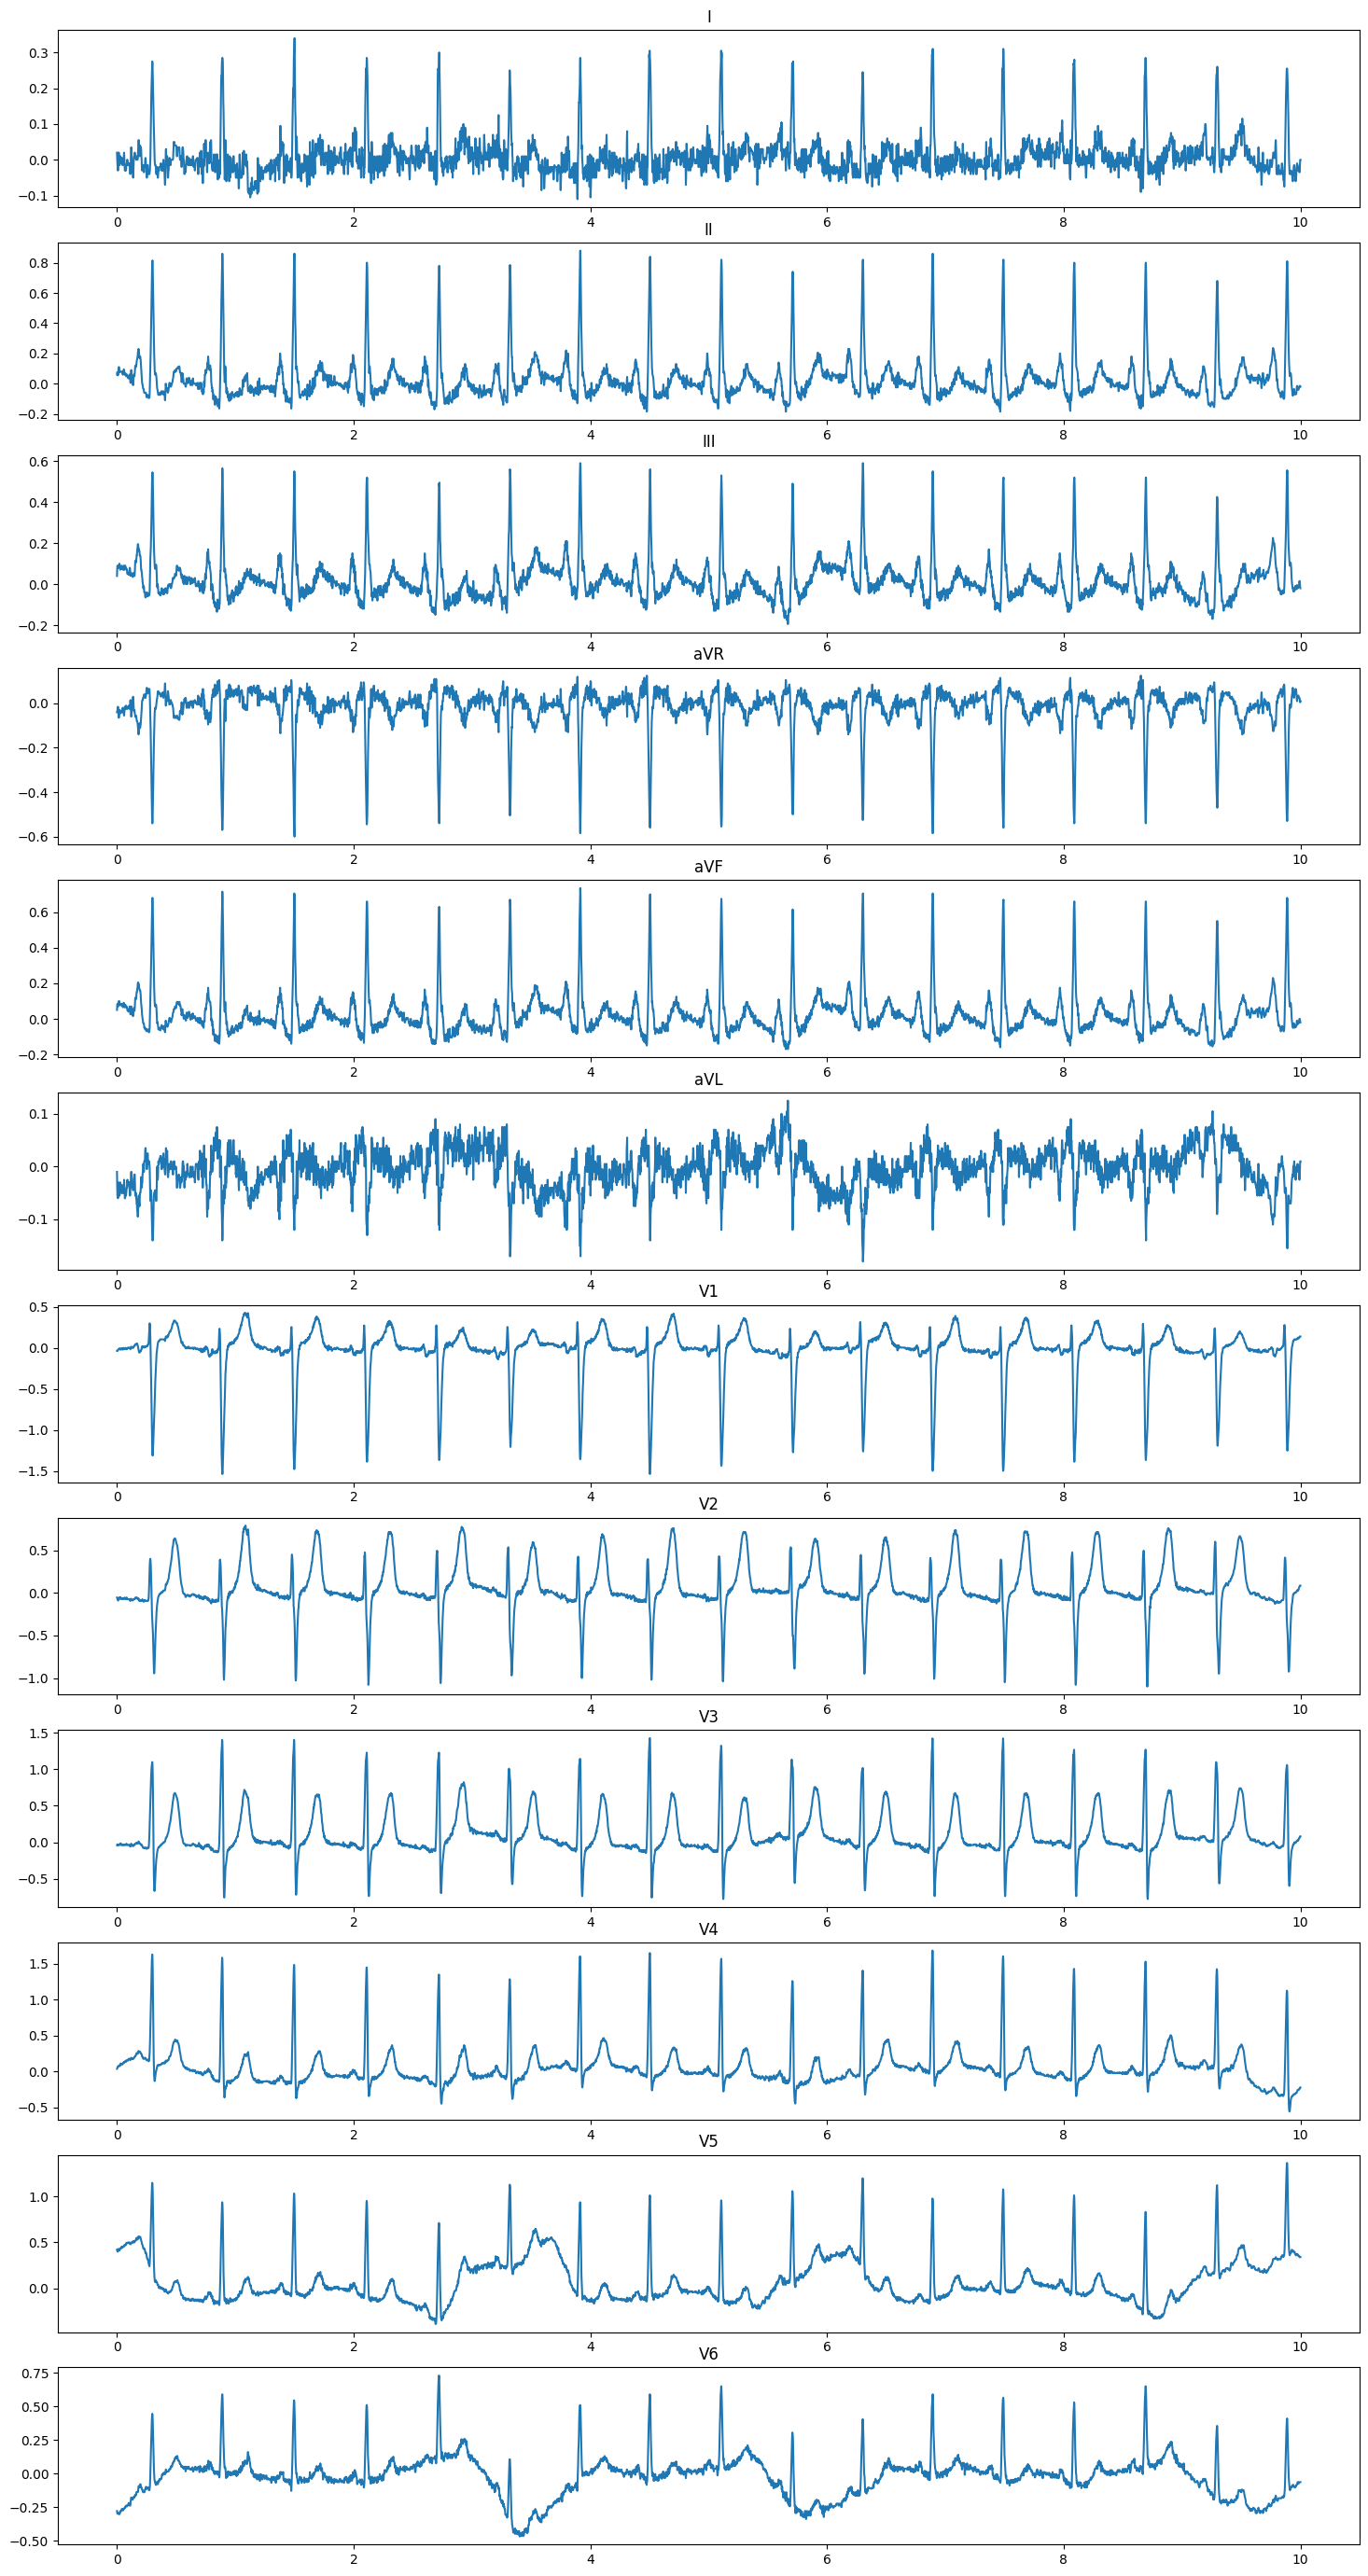

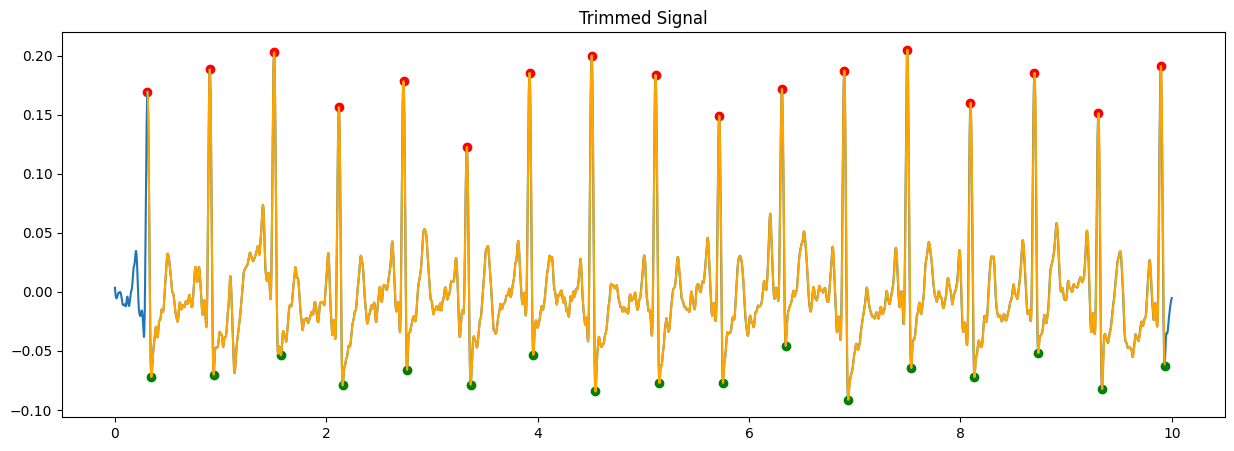

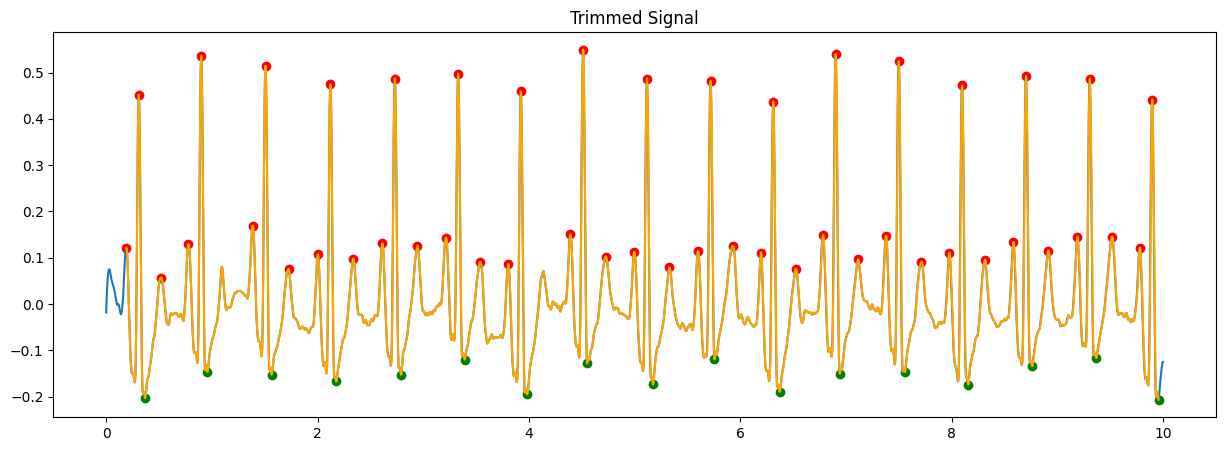

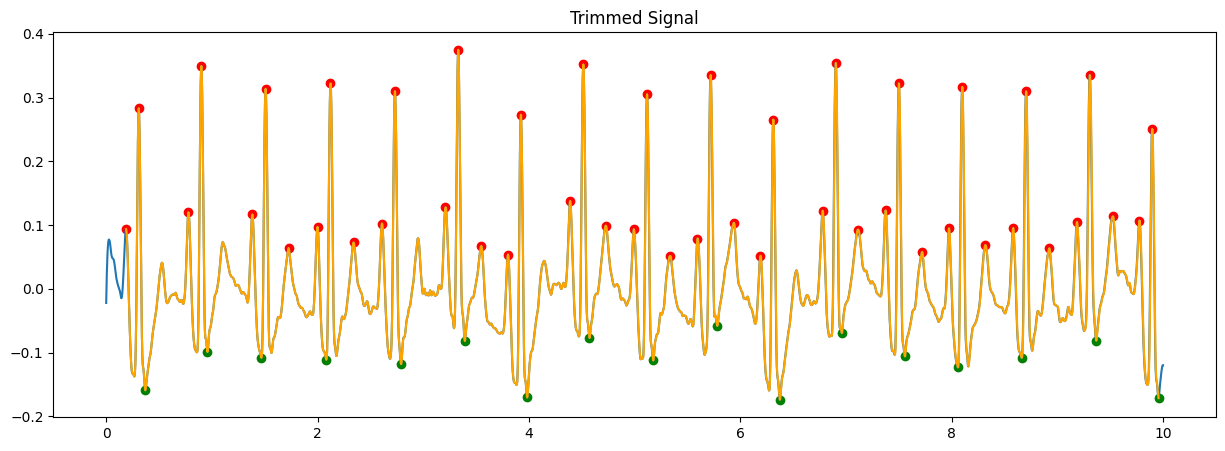

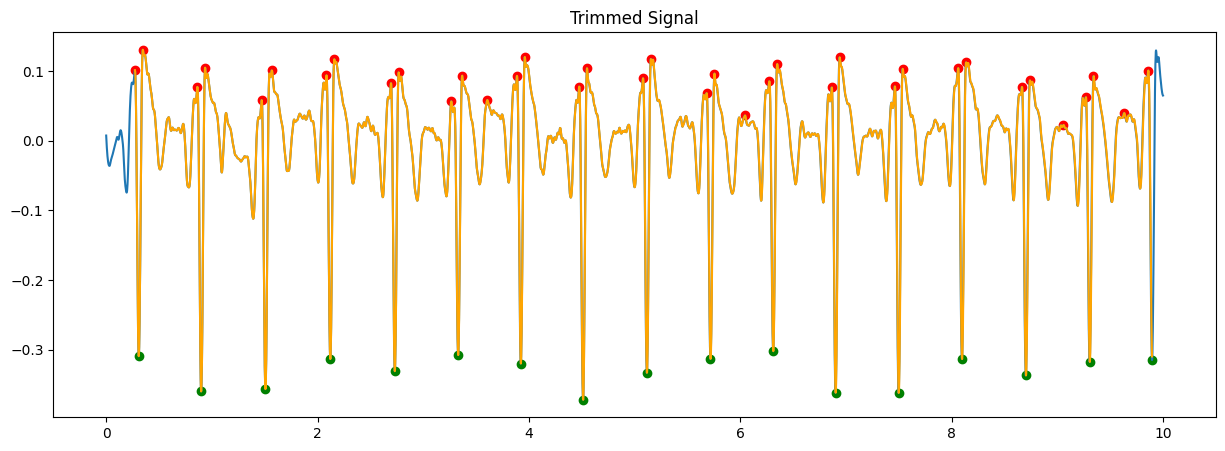

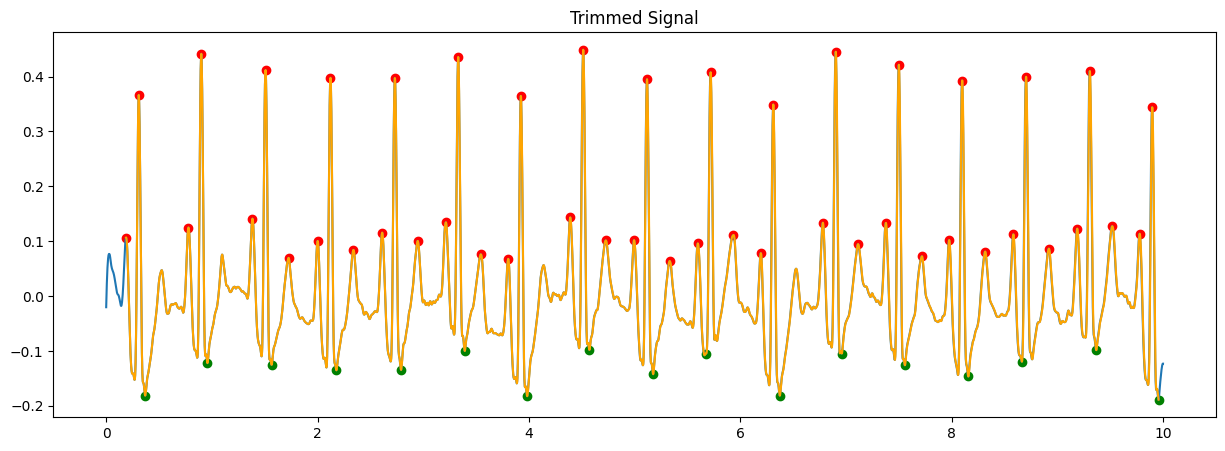

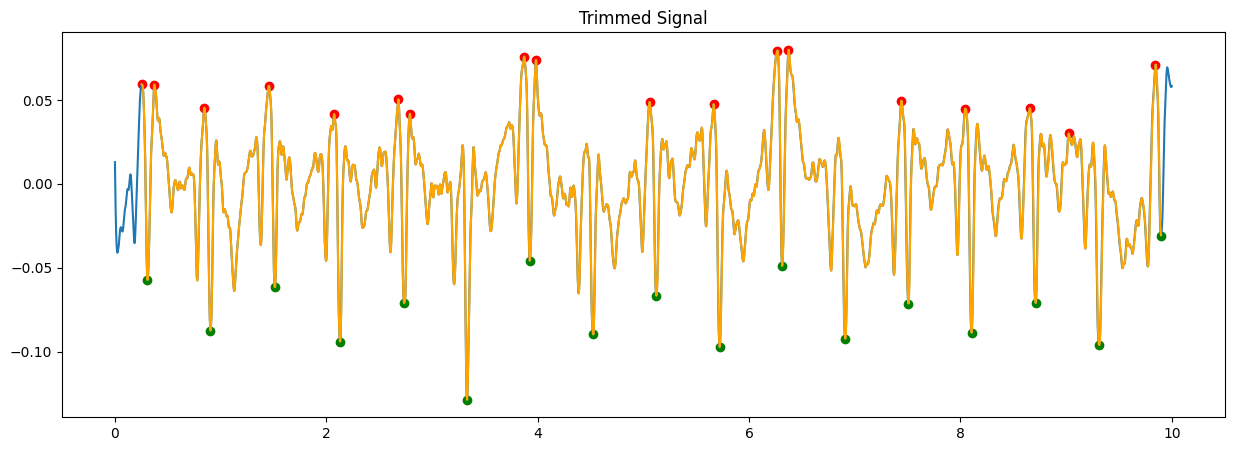

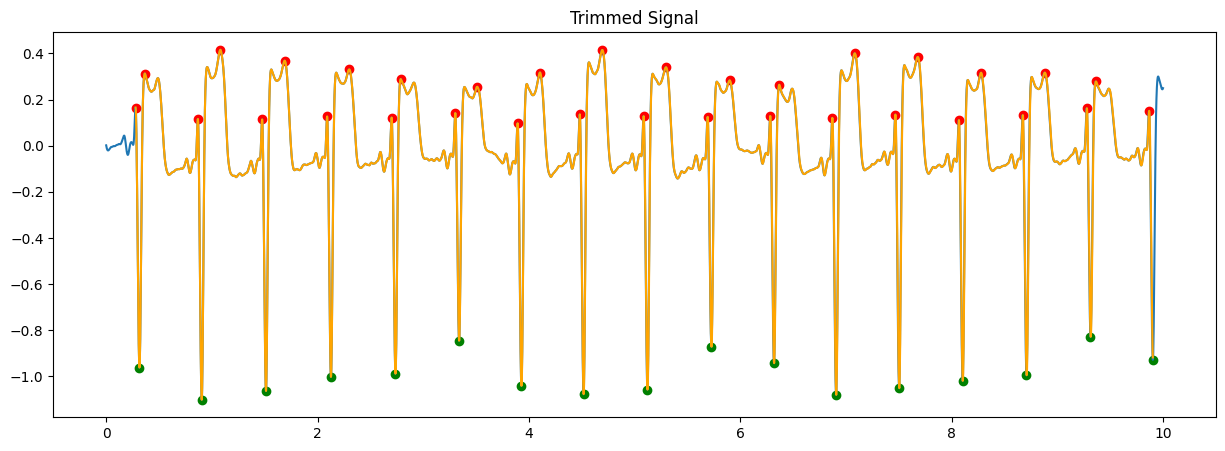

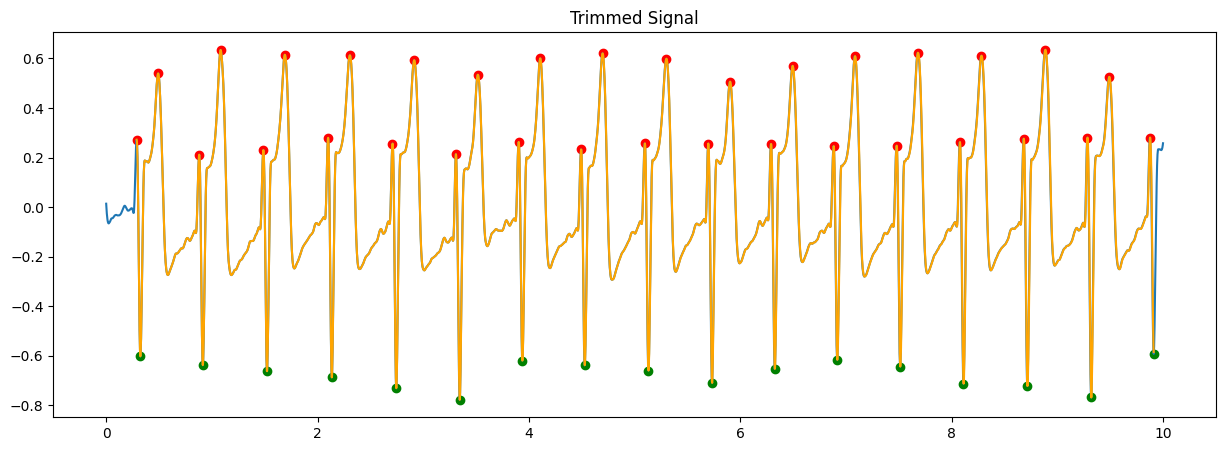

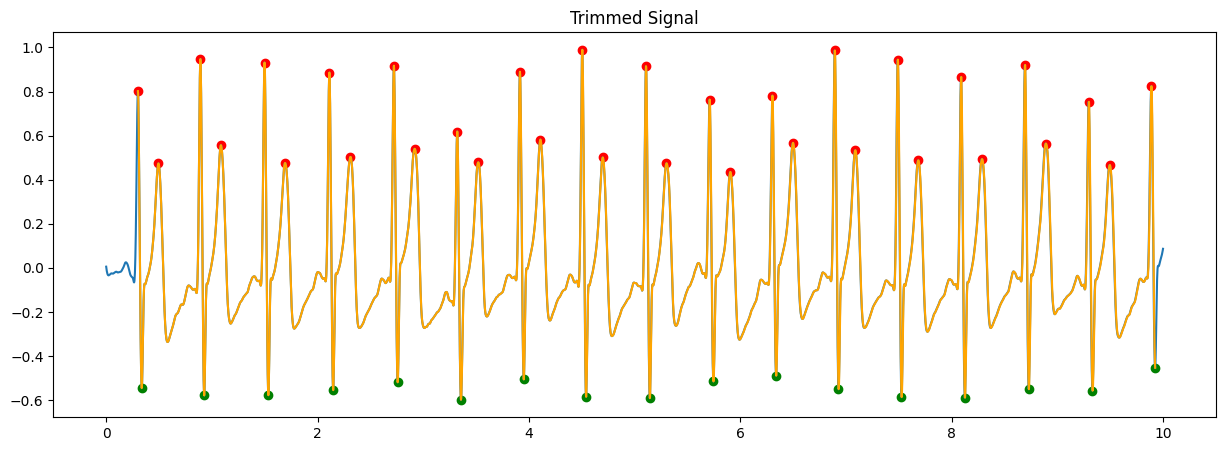

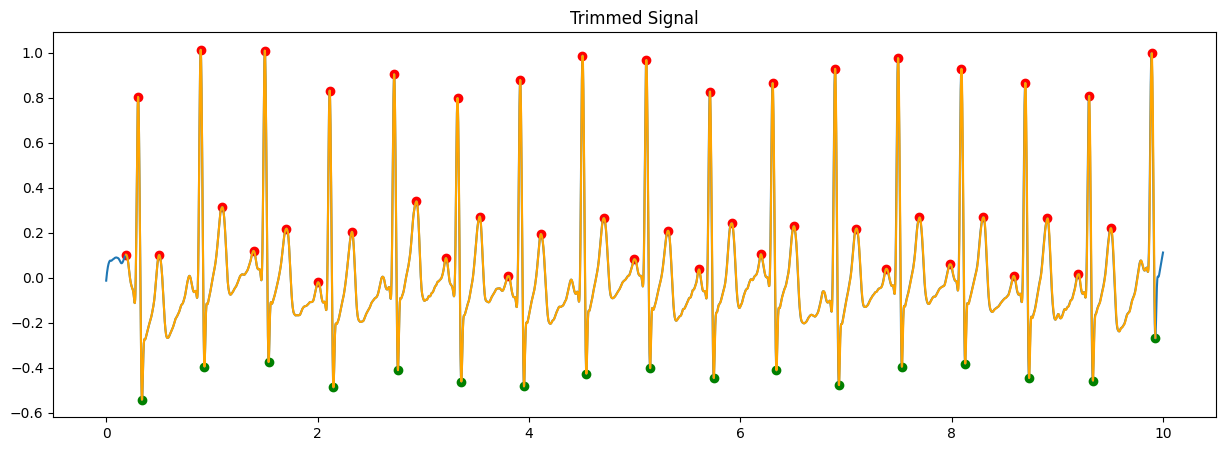

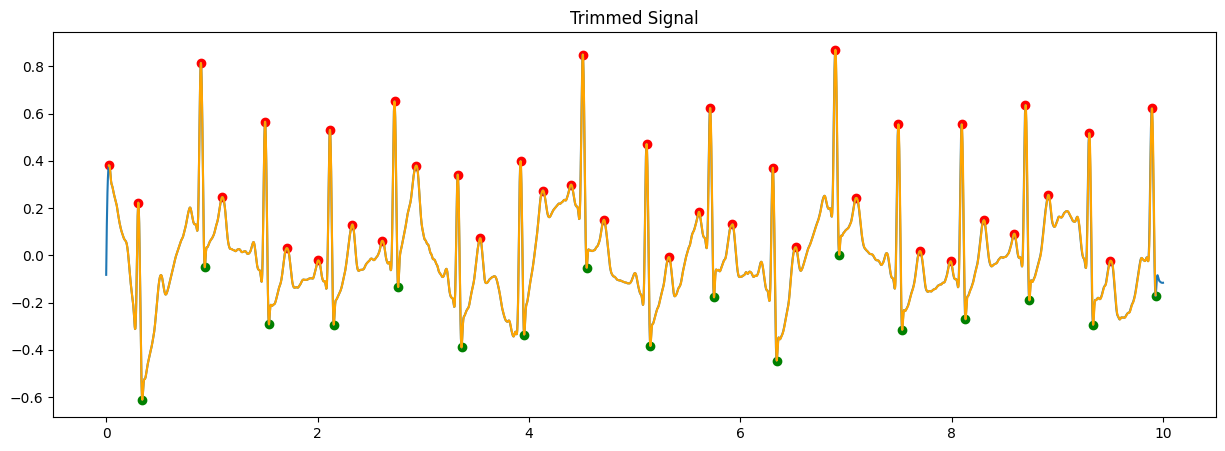

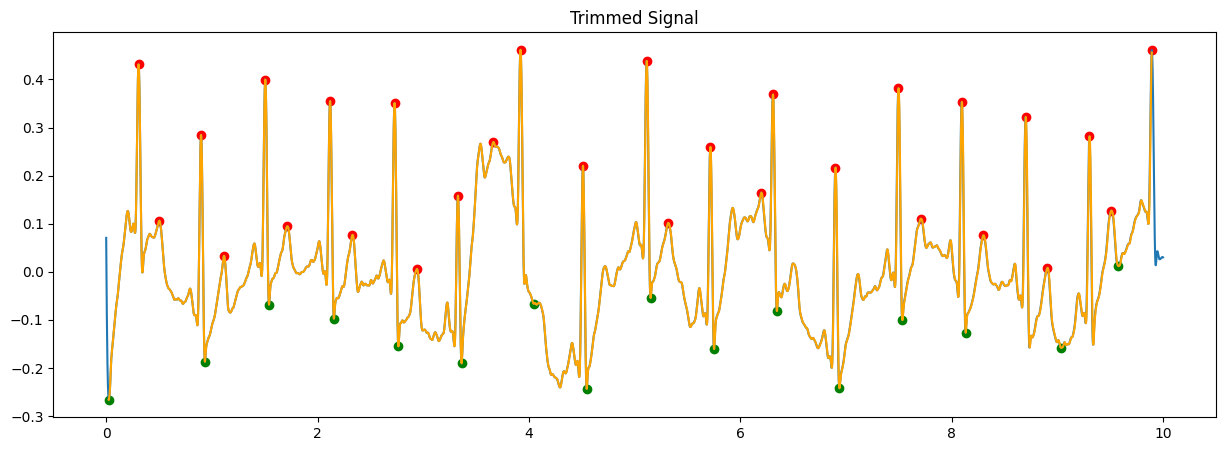

Excellent
Barely acceptable
Excellent
Excellent
Excellent
Excellent
Barely acceptable
Barely acceptable
Barely acceptable
Excellent
Barely acceptable
Barely acceptable


In [83]:
import wfdb
#import tslearn
import pandas as pd
import numpy as np
import torch
import scipy as sc
import urllib.request as ur
import csv
from pathlib import Path
import urllib.parse
from scipy import signal
import neurokit2 as nk
#from chronos import ChronosPipeline

import os
import sys
import re

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt, detrend, savgol_filter, sosfilt
from sklearn.model_selection import train_test_split


class ECGSignalProcessor:
    def __init__(self, filepath, fs=500):
        self.filepath = filepath
        self.fs = fs
        self.record = wfdb.rdrecord(filepath)
        self.n_sig = self.record.n_sig
        self.sig_len = self.record.sig_len
        self.sig_name = self.record.sig_name
        self.p_signal = np.transpose(self.record.p_signal)
        self.x = np.linspace(0, 10, self.sig_len)
        self.filtered_signal = None
        self.filtered_signal_tot = []
        self.filtered_signal_tot2 = []
        self.smooth = []
        self.filt_sig_arr = None
        self.filt_sig_arr2 = None
        self.smooth_arr = None
        self.smoothed = None
        self.detr = None
        self.detrended = []
        self.detrend_arr = None
        self.trimmed_signal = None
        self.trimmed_time = None
        self.trim = []
        self.trim_time =[]
        self.trim_arr = None
        self.trim_time_arr = None
        self.peaks = None
        self.dips = None



    def plot_signals(self):
        fig, axes = plt.subplots(nrows=self.n_sig, ncols=1, figsize=(18, 35))
        for i in range(self.n_sig):
            axes[i].plot(self.x, self.p_signal[i])
            axes[i].set_title(self.sig_name[i])
        plt.show()

    def detect_peaks_and_dips(self):

        for i in range(self.n_sig):
          self.peaks, _ = find_peaks(self.p_signal[i], distance=30, prominence=(0.1))
          self.dips, _ = find_peaks(-self.p_signal[i], distance=250)
#          plt.figure(figsize=(18, 5))
#          plt.plot(self.x, self.p_signal[i])
#          plt.plot(self.x[self.peaks], self.p_signal[i][self.peaks], 'o', color='red')
#          plt.plot(self.x[self.dips], self.p_signal[i][self.dips], 'o', color='green')
#          plt.xlabel('Time(s)')
#          plt.ylabel('Voltage(mV)')
         # plt.ylim([-1.00, 1.6])
#          plt.show()



    def apply_bandpass_filter(self, lowcut=0.5, highcut=40.0, order=4):
        nyq = 0.5 * self.fs
        sos = butter(order, [lowcut / nyq, highcut / nyq], btype='band', output='sos')
        for i in range(self.n_sig):
          self.filtered_signal = sosfilt(sos, self.p_signal[i], axis=0)
          self.filtered_signal_tot.append(self.filtered_signal)
#          plt.figure(figsize=(18, 5))
#          plt.plot(self.filtered_signal)
#          plt.title('Bandpass Filter')
#          plt.show()
        self.filt_sig_arr = np.array(self.filtered_signal_tot, dtype= 'float32')
        return self.filt_sig_arr




    def apply_notch_filter(self, filtered, freq=60.0, bandwidth=1.0, order=4):
        nyq = 0.5 * self.fs
        b, a = butter(order, [(freq - bandwidth) / nyq, (freq + bandwidth) / nyq], btype='bandstop')
        for i in range(self.n_sig):
          self.filtered_signal=filtfilt(b, a, filtered[i])
          self.filtered_signal_tot2.append(self.filtered_signal)
#          plt.figure(figsize=(18, 5))
#          plt.plot(self.filtered_signal)
#          plt.title('Powerline')
#          plt.show()
        self.filt_sig_arr2 = np.array(self.filtered_signal_tot, dtype= 'float32')
        return self.filt_sig_arr2



    def apply_savgol_filter(self, filtered, window_length=31, polyorder=3):
        for i in range(self.n_sig):
          self.smoothed = savgol_filter(filtered[i], window_length, polyorder)
          self.smooth.append(self.smoothed)
          t = np.linspace(0, 10, len(self.smoothed))
#          plt.figure(figsize=(18, 5))
#          plt.plot(t, self.smoothed)
#          plt.title('Savgol')
#          plt.show()
        self.smooth_arr = np.array(self.smooth, dtype= 'float32')
        return self.smooth_arr


    def apply_detrend(self, filtered):
        for i in range(self.n_sig):
          self.detr = detrend(filtered[i], type='linear')
          self.detrended.append(self.detr)
          t = np.linspace(0, 10, len(self.detr))
#          plt.figure(figsize=(18, 5))
#          plt.plot(t, self.detr)
#          plt.title('Detrend')
#          plt.show()
        self.detrend_arr = np.array(self.detrended, dtype='float32')
        return self.detrend_arr


    def trim_signal(self, filtered):
        for i in range(self.n_sig):
          peaks, _ = find_peaks(filtered[i], distance=30, prominence=(0.1))
          dips, _ = find_peaks(-filtered[i], distance=250)

          if peaks[0]<dips[0]:
            start_point=peaks[0]
          else:
            start_point=dips[0]


          if peaks[-1]<dips[-1]:
            end_point=dips[-1]
          else:
            end_point=peaks[-1]


          self.trimmed_signal = filtered[i][start_point:end_point]
          self.trim.append(self.trimmed_signal)
          self.trimmed_time = np.linspace(self.x[start_point], self.x[end_point], len(self.trimmed_signal))
          self.trim_time.append(self.trimmed_time)
          plt.figure(figsize=(15, 5))
          plt.plot(self.x[peaks], filtered[i][peaks], 'o', color='red')
          plt.plot(self.x[dips], filtered[i][dips], 'o', color='green')
          plt.plot(self.x, filtered[i])
          plt.plot(self.trimmed_time, self.trimmed_signal, color='orange')
          plt.title('Trimmed Signal')
          plt.show()
        self.trim_arr=np.array(self.trim, dtype='object')
        self.trim_time_arr=np.array(self.trim_time, dtype='object')
        return self.trim_arr

    def quality_check(self, trimmed):
        for i in range(self.n_sig):
          quality = nk.ecg_quality(trimmed[i], method= 'zhao2018', approach= 'fuzzy', sampling_rate=self.fs)
          print(quality)

processor = ECGSignalProcessor('102511170/102511170')
processor.plot_signals()
processor.detect_peaks_and_dips()

filt_sig_arr=processor.apply_bandpass_filter()
filt_sig_arr2=processor.apply_notch_filter(filt_sig_arr)
smooth_arr=processor.apply_savgol_filter(filt_sig_arr2)
detrend_arr=processor.apply_detrend(smooth_arr)
trimmed=processor.trim_signal(detrend_arr)
processor.quality_check(trimmed)




#pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-large",
#                        device_map="balanced", torch_dtype=torch.bfloat16)
#context=torch.tensor(trimmed__signal)
#embeddings, tokenizer_state = pipeline.embed(context)